# AI Model Experiment & Evaluation
**Starter Notebook**

Notebook ini adalah kerangka awal untuk membandingkan dua pendekatan AI dalam menyelesaikan task sentiment analysis ulasan pelanggan:
1. Model klasik Machine Learning (Scikit-learn)
2. LLM API (Gemini)

Isi tiap section sesuai instruksi di Assignment Brief. Jangan ubah struktur section, tapi silakan tambah cell baru di dalam tiap section jika diperlukan.

> 🔧 **Catatan Penyesuaian Dataset**
>
> Notebook ini menggunakan dataset `customer_reviews_sentiment.csv` dengan kolom `review_text` dan `sentiment` (nilai: `positif`/`negatif`).
>
> Apabila dataset final berbeda dari yang digunakan saat ini, sesuaikan bagian berikut:
> - Nama file pada `pd.read_csv(...)` di Section 2
> - Nama kolom teks dan label pada Section 3 (saat ini: `review_text`, `sentiment`)
> - Label yang diminta pada prompt LLM di Section 5.2 (saat ini: `positif`/`negatif`)
> - Studi Kasus pada Assignment Brief, apabila domain data berbeda dari e-commerce

## 1. Problem Statement

_Tuliskan pemahamanmu terhadap use case di sini (objective, target/label, batasan/asumsi)._

**1) objective** 

Membandingkan dua pendekatan AI untuk mengklasifikasikan sentimen berupa positif dan negatif secara otomatis dari ulasan pelanggan. Pendeketan tersebut antara lain model Machine Learning klasik menggunakan Scikit-learn dan LLM Gemini melalui API. Hasil prediksi digunakan untuk membandingkan performa dan trade-off dari kedua pendekatan.

**2) target/label**

Kategori sentimen dari ulasan pelanggan, yaitu positif dan negatif.

**3) atasan/asumsi**

- klasifikasi dibatasi pada dua kelas sentimen seseuai dengan sentimen dari dataset.
- kedua pendekatan dievaluasi menggunakan test set yang sama agar perbandingan adil. 
- Asumsi: output teks dari Gemini API bisa saja bervariasi (seperti penggunaan huruf kapital dan spasi tambahan), sehingga perlu dilakukan pembersihan berupa penghapusan whitespace dan penyesuaian huruf kecil untuk memastikan konsistensi format data dengan label acuan saat perhitungan metrik evaluasi.


## 2. Import Library & Load Dataset

In [1]:
# 🔧 Sesuaikan nama file jika dataset final berbeda
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from google import genai  
from google.genai import types
import os

df = pd.read_csv('..\data\customer_reviews_sentiment.csv')
df.head()

,review_id,product_name,review_text,sentiment
0,1,Kemeja Flanel,Pelayanan lambat dan tidak responsif saat diko...,negatif
1,2,Case HP,"Puas banget belanja disini, proses cepat dan b...",positif
2,3,Rice Cooker,"Terima kasih seller, barangnya awet dan sesuai...",positif
3,4,Case HP,Warna produk berbeda jauh dari foto di listing.,negatif
4,5,Headset Bluetooth,"Terima kasih seller, barangnya awet dan sesuai...",positif


In [2]:
# mengecek data
print("Jumlah data:", len(df))
print("\nKolom dataset:")
print(df.columns)

print("\nMissing value:")
print(df.isnull().sum())

print("\nDistribusi label:")
print(df["sentiment"].value_counts())

Jumlah data: 200

Kolom dataset:
Index(['review_id', 'product_name', 'review_text', 'sentiment'], dtype='str')

Missing value:
review_id       0
product_name    0
review_text     0
sentiment       0
dtype: int64

Distribusi label:
sentiment
positif    110
negatif     90
Name: count, dtype: int64


## 3. Menyiapkan Train/Test Split

Pastikan test set yang sama digunakan untuk kedua pendekatan agar perbandingan adil.

In [3]:
# 🔧 Sesuaikan nama kolom jika dataset final menggunakan nama kolom berbeda
X = df['review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

Train size: 160
Test size: 40


## 4. Pendekatan 1 — Model Klasik (Scikit-learn)

### 4.1 Preprocessing & Feature Extraction

In [4]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

### 4.2 Training Model

In [5]:
clf = LogisticRegression()
clf.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

### 4.3 Prediksi pada Test Set

In [6]:
y_pred_classic = clf.predict(X_test_vec)

In [7]:
# # melihat perbandingan hasil prediksi dengan nilai aktual

print("Jumlah prediksi:", len(y_pred_classic))

result_classic = pd.DataFrame({
    'review_text': X_test.values,
    'actual': y_test.values,
    'predicted_classic': y_pred_classic
})

result_classic.head(10)


Jumlah prediksi: 40


,review_text,actual,predicted_classic
0,Barang tidak berfungsi sama sekali begitu dite...,negatif,negatif
1,"Sudah langganan di toko ini, kualitas selalu k...",positif,positif
2,"Suka banget sama warnanya, sesuai ekspektasi.",positif,positif
3,"Kualitas produk sangat memuaskan, akan order l...",positif,positif
4,"Ukuran tidak sesuai, terlalu kecil dari yang d...",negatif,negatif
5,Sudah bayar mahal tapi kualitas jauh dari eksp...,negatif,negatif
6,"Suka banget sama warnanya, sesuai ekspektasi.",positif,positif
7,"Fast respon, pengiriman cepat, barang aman sam...",positif,positif
8,"Produk palsu, bukan barang original seperti ya...",negatif,negatif
9,Komplain tidak ditanggapi sama sekali oleh pen...,negatif,negatif


## 5. Pendekatan 2 — LLM API (Gemini)

### 5.1 Setup API

In [8]:
# Simpan API key di environment variable, JANGAN hardcode langsung di notebook
client = genai.Client(api_key=os.environ.get('GEMINI_API_KEY'))

### 5.2 Merancang Prompt

_Pada eksperimen ini, zero-shot prompting digunakan karena tugas yang dilakukan berupa klasifikasi sentimen berupa positif atau negatif dari sebuah review text. Tugasnya cukup jelas, sentimen dapat dipahami oleh LLM melalui semantic understanding dari review text, dan instruksi dan pilihan label sudah cukup untuk membuat model menghasilkan prediksi tanpa harus diberikan contoh terlebih dahulu. Kemudian, Temperature sebesar 0.2 digunakan karena task bersifat klasifikasi sehingga dibutuhkan output yang lebih konsisten atau tidak terlalu variatif._

In [9]:
# 🔧 Sesuaikan label pada prompt jika dataset final menggunakan label berbeda
def classify_sentiment_llm(review_text):
    prompt = f'''Klasifikasikan sentimen ulasan berikut sebagai "positif" atau "negatif".
Jawab hanya dengan satu kata: positif atau negatif.

Ulasan: "{review_text}"
Sentimen:'''
    response = client.models.generate_content(
        model='gemini-3.5-flash-lite',  # sesuaikan versi model
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2)
    )
    return response.text.strip().lower()

### 5.3 Menjalankan Prediksi pada Test Set

Catatan: lakukan normalisasi terhadap output LLM sebelum dibandingkan dengan label asli (misal: lowercase, strip whitespace).

In [10]:
import time

y_pred_llm = []
for review in X_test:
    pred = classify_sentiment_llm(review)
    y_pred_llm.append(pred)
    
    time.sleep(5) # perlu time sleep karena free tier hanya memberikan 15 Request per Minute (RPM)


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


In [11]:
# TODO: normalisasi y_pred_llm agar konsisten dengan label 'positif'/'negatif'

y_pred_llm_cleaned = []

for pred in y_pred_llm:
    cleaned_pred = pred.strip().lower()
    y_pred_llm_cleaned.append(cleaned_pred)

y_pred_llm = y_pred_llm_cleaned

In [12]:
# melihat perbandingan hasil prediksi dengan nilai aktual

print("Jumlah prediksi:", len(y_pred_llm))

result_llm = pd.DataFrame({
    'review_text': X_test.values,
    'actual': y_test.values,
    'predicted_llm': y_pred_llm
})

result_llm.head(10)


Jumlah prediksi: 40


,review_text,actual,predicted_llm
0,Barang tidak berfungsi sama sekali begitu dite...,negatif,negatif
1,"Sudah langganan di toko ini, kualitas selalu k...",positif,positif
2,"Suka banget sama warnanya, sesuai ekspektasi.",positif,positif
3,"Kualitas produk sangat memuaskan, akan order l...",positif,positif
4,"Ukuran tidak sesuai, terlalu kecil dari yang d...",negatif,negatif
5,Sudah bayar mahal tapi kualitas jauh dari eksp...,negatif,negatif
6,"Suka banget sama warnanya, sesuai ekspektasi.",positif,positif
7,"Fast respon, pengiriman cepat, barang aman sam...",positif,positif
8,"Produk palsu, bukan barang original seperti ya...",negatif,negatif
9,Komplain tidak ditanggapi sama sekali oleh pen...,negatif,negatif


## 6. Evaluasi dan Perbandingan

### 6.1 Evaluasi Model Klasik

In [13]:
print('=== Model Klasik (Scikit-learn) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_classic))
print(classification_report(y_test, y_pred_classic))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_classic))

=== Model Klasik (Scikit-learn) ===
Accuracy: 1.0
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.2 Evaluasi LLM API

In [14]:
print('=== LLM API (Gemini) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_llm))
print(classification_report(y_test, y_pred_llm))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_llm))

=== LLM API (Gemini) ===
Accuracy: 1.0
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.3 Tabel Perbandingan Ringkasan

_Susun tabel ringkasan (bisa markdown table atau DataFrame) yang membandingkan Accuracy, Precision, Recall, F1-Score kedua pendekatan._

In [15]:
evaluation_score_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],

    'ML Classic': [
        accuracy_score(y_test, y_pred_classic),
        precision_score(y_test, y_pred_classic, pos_label='positif'),
        recall_score(y_test, y_pred_classic, pos_label='positif'),
        f1_score(y_test, y_pred_classic, pos_label='positif')
    ],

    'LLM Gemini': [
        accuracy_score(y_test, y_pred_llm),
        precision_score(y_test, y_pred_llm, pos_label='positif'),
        recall_score(y_test, y_pred_llm, pos_label='positif'),
        f1_score(y_test, y_pred_llm, pos_label='positif')
    ]
})

evaluation_score_df

,Metric,ML Classic,LLM Gemini
0,Accuracy,1.0,1.0
1,Precision,1.0,1.0
2,Recall,1.0,1.0
3,F1-Score,1.0,1.0


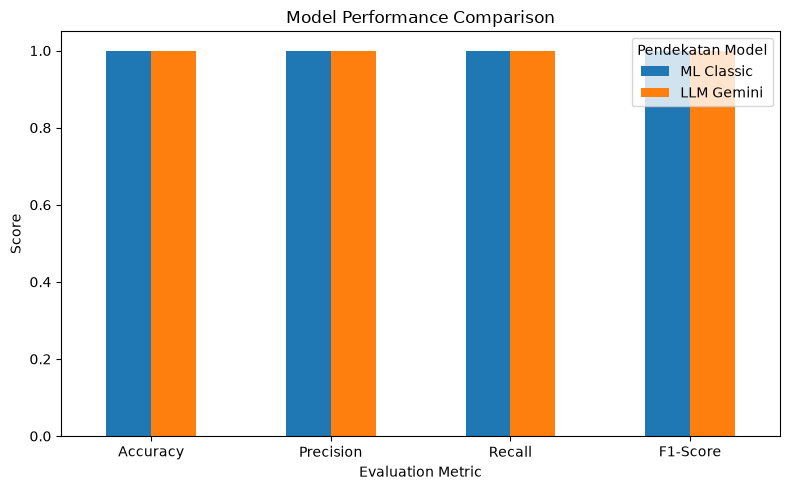

In [16]:
import matplotlib.pyplot as plt

ax = evaluation_score_df.set_index('Metric').plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Model Performance Comparison')
plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Pendekatan Model')
plt.tight_layout()

plt.savefig(
    '../documentation/model_comparison_summary.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 6.4 Interpretasi metrik evaluasi

_Berdasarkan hasil evaluasi, ML Classic dan LLM Gemini memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 1.0 atau 100%. Hal ini menunjukkan bahwa kedua pendekatan mampu mengklasifikasikan seluruh data pada test set dengan benar. Nilai Precision dan Recall sebesar 100% juga menunjukkan bahwa tidak terdapat kesalahan prediksi berupa false positive maupun false negative pada kelas positif, sedangkan nilai F1-Score sebesar 100% menunjukkan kedua pendekatan sama-sama optimal dan seimbang._

## 7. Analisis Trade-off dan Limitation


_Berdasarkan hasil eksperimen, model ML klasik dan LLM Gemini API menunjukkan performa yang sama pada test set, dengan Accuracy, Precision, Recall, dan F1-Score sebesar 100%. Oleh karena itu, pada eksperimen ini belum terdapat perbedaan performa yang signifikan antara kedua pendekatan. Dari sisi effort implementasi, ML klasik membutuhkan proses preprocessing menggunakan TF-IDF dan training Logistic Regression untuk mempelajari pola dari data training, sedangkan Gemini dapat langsung melakukan klasifikasi melalui prompt tanpa proses training. Dari sisi kecepatan, ML klasik lebih cepat pada eksperimen ini karena dataset yang digunakan relatif kecil, yaitu 160 data training dan 40 data testing, serta proses training dan inference dapat dilakukan langsung pada CPU laptop. Gemini API cenderung lebih lambat karena setiap prediksi memerlukan komunikasi melalui API sehingga terdapat network latency serta batas request seperti RPM pada free tier. Dari sisi biaya, ML klasik relatif murah karena setelah model dilatih, prediksi dapat dilakukan secara lokal tanpa biaya per request, sedangkan Gemini API memiliki potensi biaya berdasarkan jumlah request dan token yang digunakan jika penggunaan meningkat. Keterbatasan ML klasik adalah kemampuan memahami konteks semantik yang lebih terbatas karena TF-IDF lebih berfokus pada pola kata, sehingga dapat mengalami kesulitan pada kalimat yang lebih kompleks, ambigu, atau memiliki konteks tertentu. Sementara itu, Gemini memiliki kemampuan pemahaman bahasa yang lebih baik dan tidak memerlukan training khusus, tetapi memiliki ketergantungan terhadap koneksi internet, layanan API, rate limit, latency, serta potensi biaya penggunaan. Sehingga, pada studi kasus dalam eksperimen di atas, penggunaan ML Klasik lebih unggul dari sisi efisiensi implementasi, kecepatan inference, dan biaya, karena mampu mencapai performa evaluasi yang sama dengan Gemini tanpa ketergantungan pada API. Namun, jika ulasan pelanggan mulai lebih kompleks, ambigu, dan berdasarkan konteks tertentu atau membutuhkan pemahaman makna yang lebih mendalam, maka LLM Gemini API dapat menjadi pendekatan yang lebih sesuai karena memiliki kemampuan pemahaman semantik dan konteks bahasa yang lebih baik dibandingkan pendekatan TF-IDF dan Logistic Regression._

## 8. Rekomendasi Technical Approach

_Berdasarkan hasil eksperimen, ML Klasik menggunakan TF-IDF dan Logistic Regression direkomendasikan sebagai pendekatan utama untuk studi kasus ini. Kedua pendekatan, yaitu ML Klasik dan LLM Gemini API, memperoleh Accuracy, Precision, Recall, dan F1-Score sebesar 100%, sehingga dari sisi performa keduanya memberikan hasil yang sama pada test set yang digunakan. Namun, ML Klasik lebih efisien dari sisi kecepatan inference dan biaya karena proses prediksi dapat dilakukan secara lokal tanpa ketergantungan pada koneksi internet, API, rate limit, maupun biaya penggunaan per request. Selain itu, model yang digunakan relatif ringan sehingga dapat dijalankan menggunakan CPU pada laptop untuk dataset dengan skala seperti pada eksperimen ini. Namun, apabila ke depannya karakteristik ulasan menjadi lebih kompleks maka pendekatan berbasis LLM seperti Gemini API dapat dipertimbangkan karena memiliki kemampuan pemahaman konteks bahasa yang lebih baik dibandingkan pendekatan TF-IDF. Dengan demikian, untuk kebutuhan saat ini ML Klasik lebih sesuai dari sisi efisiensi dan performa, sedangkan LLM dapat dipertimbangkan ketika kompleksitas data dan disaat kasus dengan pemahaman bahasa meningkat._